<a href="https://colab.research.google.com/github/de-fernandez/CPE-313-CPE32S3/blob/main/%5BGroup%2010%5D%2C%20CPE32S3%2C%20CPE%20313%20(Hands-On-Activity%207.2%20-%20CNN%20Architectures%20from%20Scratch%20and%20Transfer%20Learning).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Procedure

1. Create a VGG-16 Network from scratch.
2. Train on the given datasetLinks to an external site. and reach at least 95% Accuracy. Do not use pre-trained weights.
3. Plot the accuracy for both Training and Validation. Include a confusion matrix, and a classification report (Precision, Recall , F1 score, Sensitivity) Plot the ROC AUC score result of the model
4. Interpret and evaluate the result of the model.
5. Import a pretrained VGG-16 Network, adjust the final layers to match the dataset. Must have pre-trained weights.
6. Fine tune on the given dataset, plot the same metrics in #3 and #4.
7. Compare the results of the trained network from scratch and fine-tuned network.

## From Scratch VGG16

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout
from tensorflow.keras.optimizers import Adam
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import confusion_matrix, classification_report, roc_auc_score, roc_curve
import seaborn as sns
import os

In [ ]:
import os
import tensorflow as tf
from tensorflow.keras.layers import Rescaling, RandomFlip, RandomRotation, RandomZoom, RandomContrast

data_dir = r'/content/drive/MyDrive/CPE313/HOA7.2/FastAI_ImageNet_v2'
train_dir = os.path.join(data_dir, 'train')
val_dir = os.path.join(data_dir, 'val')

img_height, img_width = 160, 160
batch_size = 32

train_ds_raw = tf.keras.utils.image_dataset_from_directory(
    train_dir,
    image_size=(img_height, img_width),
    batch_size=batch_size,
    label_mode='categorical'
)

val_ds_raw = tf.keras.utils.image_dataset_from_directory(
    val_dir,
    image_size=(img_height, img_width),
    batch_size=batch_size,
    label_mode='categorical'
)

class_names = train_ds_raw.class_names
num_classes = len(class_names)
print("Classes:", class_names)

data_augmentation = tf.keras.Sequential([
    tf.keras.layers.RandomFlip("horizontal"),
    tf.keras.layers.RandomRotation(0.2),
    tf.keras.layers.RandomZoom(0.2),
    tf.keras.layers.RandomContrast(0.2),
])

normalization = Rescaling(1./255)

AUTOTUNE = tf.data.AUTOTUNE

train_ds = (
    train_ds_raw
    .shuffle(1000)
    .map(lambda x, y: (data_augmentation(x, training=True), y), num_parallel_calls=AUTOTUNE)
    .map(lambda x, y: (normalization(x), y), num_parallel_calls=AUTOTUNE)
    .cache()
    .prefetch(buffer_size=AUTOTUNE)
)

val_ds = (
    val_ds_raw
    .map(lambda x, y: (normalization(x), y), num_parallel_calls=AUTOTUNE)
    .cache()
    .prefetch(buffer_size=AUTOTUNE)
)

Found 9469 files belonging to 10 classes.
Found 3925 files belonging to 10 classes.
Classes: ['cassette_player', 'chain_saw', 'church', 'english_springer', 'french_horn', 'garbage_truck', 'gas_pump', 'golf_ball', 'parachute', 'tench']


In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, GlobalAveragePooling2D
from tensorflow.keras.layers import Dense, Dropout, BatchNormalization, Input
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.regularizers import l2
from tensorflow.keras.callbacks import ReduceLROnPlateau, EarlyStopping

weight_decay = 1e-4

vgg16_scratch = Sequential([

    Input(shape=(160, 160, 3)),

    # BLOCK 1 (simple edge features)
    Conv2D(32, (3,3), padding='same', activation='relu', kernel_regularizer=l2(weight_decay)),
    BatchNormalization(),
    Conv2D(32, (3,3), padding='same', activation='relu', kernel_regularizer=l2(weight_decay)),
    BatchNormalization(),
    MaxPooling2D(),

    # BLOCK 2
    Conv2D(64, (3,3), padding='same', activation='relu', kernel_regularizer=l2(weight_decay)),
    BatchNormalization(),
    Conv2D(64, (3,3), padding='same', activation='relu', kernel_regularizer=l2(weight_decay)),
    BatchNormalization(),
    MaxPooling2D(),

    # BLOCK 3
    Conv2D(128, (3,3), padding='same', activation='relu', kernel_regularizer=l2(weight_decay)),
    BatchNormalization(),
    Conv2D(128, (3,3), padding='same', activation='relu', kernel_regularizer=l2(weight_decay)),
    BatchNormalization(),
    MaxPooling2D(),

    # BLOCK 4
    Conv2D(256, (3,3), padding='same', activation='relu', kernel_regularizer=l2(weight_decay)),
    BatchNormalization(),
    Conv2D(256, (3,3), padding='same', activation='relu', kernel_regularizer=l2(weight_decay)),
    BatchNormalization(),
    MaxPooling2D(),
    Dropout(0.3),

    # CLASSIFIER
    GlobalAveragePooling2D(),

    Dense(256, activation='relu'),
    BatchNormalization(),
    Dropout(0.4),

    Dense(128, activation='relu'),
    BatchNormalization(),
    Dropout(0.3),

    Dense(num_classes, activation='softmax')
])

callbacks = [
    EarlyStopping(
        monitor='val_accuracy',
        patience=7,
        restore_best_weights=True
    ),
    ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.3,
        patience=3,
        min_lr=1e-6
    )
]

vgg16_scratch.compile(
    optimizer=Adam(learning_rate=3e-4),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

history = vgg16_scratch.fit(
    train_ds,
    validation_data=val_ds,
    epochs=50,
    callbacks=callbacks
)

Epoch 1/50
296/296 ━━━━━━━━━━━━━━━━━━━━ 76s 175ms/step - accuracy: 0.2878 - loss: 2.3098 - val_accuracy: 0.1045 - val_loss: 4.5024 - learning_rate: 3.0000e-04
Epoch 2/50
296/296 ━━━━━━━━━━━━━━━━━━━━ 29s 97ms/step - accuracy: 0.3828 - loss: 1.9546 - val_accuracy: 0.3758 - val_loss: 1.9192 - learning_rate: 3.0000e-04
Epoch 3/50
296/296 ━━━━━━━━━━━━━━━━━━━━ 29s 97ms/step - accuracy: 0.4347 - loss: 1.7775 - val_accuracy: 0.4183 - val_loss: 2.0681 - learning_rate: 3.0000e-04
Epoch 4/50
296/296 ━━━━━━━━━━━━━━━━━━━━ 29s 98ms/step - accuracy: 0.4863 - loss: 1.6437 - val_accuracy: 0.4112 - val_loss: 1.8817 - learning_rate: 3.0000e-04
Epoch 5/50
296/296 ━━━━━━━━━━━━━━━━━━━━ 41s 97ms/step - accuracy: 0.5289 - loss: 1.5230 - val_accuracy: 0.4754 - val_loss: 1.6949 - learning_rate: 3.0000e-04
Epoch 6/50
296/296 ━━━━━━━━━━━━━━━━━━━━ 29s 98ms/step - accuracy: 0.5606 - loss: 1.4252 - val_accuracy: 0.5014 - val_loss: 1.6089 - learning_rate: 3.0000e-04
Epoch 7/50
296/296 ━━━━━━━━━━━━━━━━━━━━ 28s 96ms/st

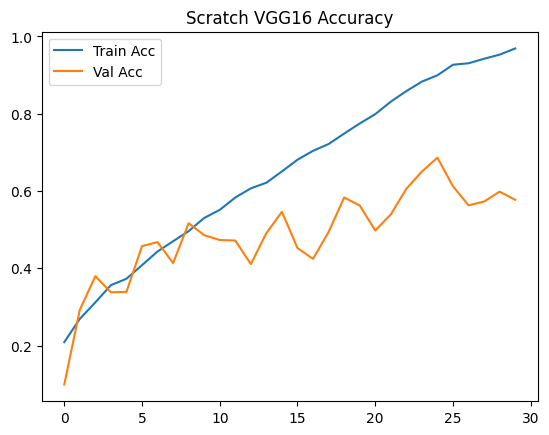

123/123 ━━━━━━━━━━━━━━━━━━━━ 10s 79ms/step


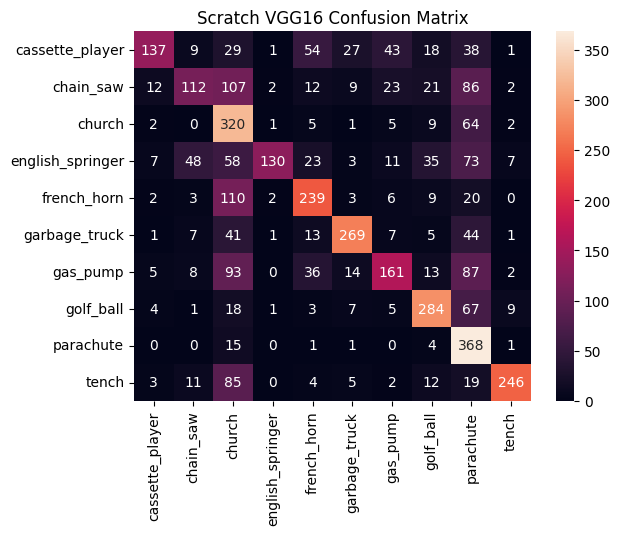

                  precision    recall  f1-score   support

 cassette_player       0.79      0.38      0.52       357
       chain_saw       0.56      0.29      0.38       386
          church       0.37      0.78      0.50       409
english_springer       0.94      0.33      0.49       395
     french_horn       0.61      0.61      0.61       394
   garbage_truck       0.79      0.69      0.74       389
        gas_pump       0.61      0.38      0.47       419
       golf_ball       0.69      0.71      0.70       399
       parachute       0.42      0.94      0.59       390
           tench       0.91      0.64      0.75       387

        accuracy                           0.58      3925
       macro avg       0.67      0.58      0.57      3925
    weighted avg       0.67      0.58      0.57      3925

Scratch VGG16 ROC AUC: 0.9088503883193179


In [ ]:
# Accuracy plot
plt.plot(history_vgg16_scratch.history['accuracy'], label='Train Acc')
plt.plot(history_vgg16_scratch.history['val_accuracy'], label='Val Acc')
plt.legend(); plt.title("Scratch VGG16 Accuracy"); plt.show()

# Predictions
y_pred = vgg16_scratch.predict(val_ds, verbose=1)

# TRUE labels (convert properly)
y_true = []
for _, y in val_ds:
    y_true.append(y.numpy())

y_true = np.concatenate(y_true, axis=0)

# Convert to class index safely
if len(y_true.shape) > 1:
    y_true_classes = np.argmax(y_true, axis=1)
else:
    y_true_classes = y_true

y_pred_classes = np.argmax(y_pred, axis=1)
# Confusion Matrix
cm = confusion_matrix(y_true_classes, y_pred_classes)
sns.heatmap(cm, annot=True, fmt='d', xticklabels=class_names, yticklabels=class_names)
plt.title("Scratch VGG16 Confusion Matrix"); plt.show()

# Classification Report
print(classification_report(y_true_classes, y_pred_classes, target_names=class_names))

# ROC AUC
roc_auc = roc_auc_score(y_true, y_pred, multi_class='ovr')
print("Scratch VGG16 ROC AUC:", roc_auc)

**Analysis:** The scratch VGG16 model learned the training data properly but struggled on the validation data. The training accuracy climbed well, but validation accuracy became unstable, this shows overfitting. Some classes were classified correctly while others were often misclassified, which result to overall accuracy of about 58%. The ROC AUC was high, which means the model could make predictions well, but the actual classifications were inconsistent.

## Pretrained VGG16

In [ ]:
from tensorflow.keras.applications import VGG16
from tensorflow.keras.models import Model
from tensorflow.keras.layers import GlobalAveragePooling2D, Dense, Dropout
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.regularizers import l2
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
import tensorflow as tf

# Pretrained VGG16
base_model = VGG16(weights='imagenet', include_top=False, input_shape=(160,160,3))

for layer in base_model.layers:
    layer.trainable = False

x = GlobalAveragePooling2D()(base_model.output)
x = Dense(256, activation='relu', kernel_regularizer=l2(1e-5))(x)
x = Dropout(0.5)(x)
x = Dense(128, activation='relu', kernel_regularizer=l2(1e-5))(x)
x = Dropout(0.3)(x)
output = Dense(num_classes, activation='softmax')(x)

vgg16_pretrained = Model(inputs=base_model.input, outputs=output)
vgg16_pretrained.compile(optimizer=Adam(learning_rate=0.0001), loss='categorical_crossentropy', metrics=['accuracy'])
history_vgg16_pretrained = vgg16_pretrained.fit(train_ds, epochs=20, validation_data=val_ds)

# Fine-tune
for layer in base_model.layers[-8:]:
    layer.trainable = True

vgg16_pretrained.compile(optimizer=Adam(learning_rate=5e-5), loss=tf.keras.losses.CategoricalCrossentropy(label_smoothing=0.1), metrics=['accuracy'])
callbacks = [EarlyStopping(patience=5, restore_best_weights=True), ReduceLROnPlateau(factor=0.3, patience=3, min_lr=1e-6)]
history_vgg16_finetune = vgg16_pretrained.fit(train_ds, epochs=20, validation_data=val_ds, callbacks=callbacks)

58889256/58889256 ━━━━━━━━━━━━━━━━━━━━ 4s 0us/step
Epoch 1/20
296/296 ━━━━━━━━━━━━━━━━━━━━ 66s 205ms/step - accuracy: 0.1936 - loss: 2.2087 - val_accuracy: 0.4899 - val_loss: 1.8270
Epoch 2/20
296/296 ━━━━━━━━━━━━━━━━━━━━ 47s 158ms/step - accuracy: 0.3925 - loss: 1.7317 - val_accuracy: 0.5776 - val_loss: 1.3734
Epoch 3/20
296/296 ━━━━━━━━━━━━━━━━━━━━ 48s 161ms/step - accuracy: 0.4928 - loss: 1.4602 - val_accuracy: 0.6390 - val_loss: 1.1581
Epoch 4/20
296/296 ━━━━━━━━━━━━━━━━━━━━ 47s 159ms/step - accuracy: 0.5425 - loss: 1.3159 - val_accuracy: 0.6902 - val_loss: 1.0143
Epoch 5/20
296/296 ━━━━━━━━━━━━━━━━━━━━ 47s 160ms/step - accuracy: 0.5767 - loss: 1.2216 - val_accuracy: 0.7154 - val_loss: 0.9242
Epoch 6/20
296/296 ━━━━━━━━━━━━━━━━━━━━ 47s 159ms/step - accuracy: 0.6072 - loss: 1.1486 - val_accuracy: 0.7350 - val_loss: 0.8534
Epoch 7/20
296/296 ━━━━━━━━━━━━━━━━━━━━ 47s 159ms/step - accuracy: 0.6294 - loss: 1.0864 - val_accuracy: 0.7513 - val_loss: 0.7899
Epoch 8/20
296/296 ━━━━━━━━━━━━━

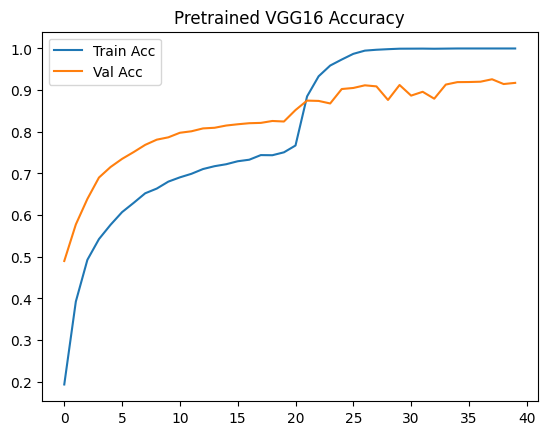

123/123 ━━━━━━━━━━━━━━━━━━━━ 15s 115ms/step


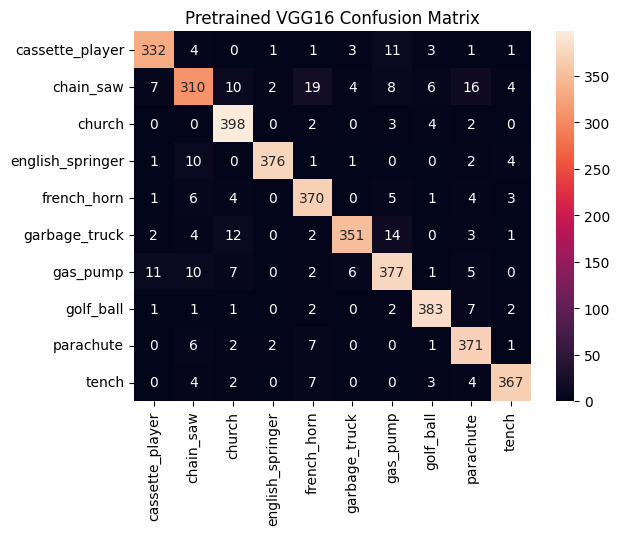

                  precision    recall  f1-score   support

 cassette_player       0.94      0.93      0.93       357
       chain_saw       0.87      0.80      0.84       386
          church       0.91      0.97      0.94       409
english_springer       0.99      0.95      0.97       395
     french_horn       0.90      0.94      0.92       394
   garbage_truck       0.96      0.90      0.93       389
        gas_pump       0.90      0.90      0.90       419
       golf_ball       0.95      0.96      0.96       399
       parachute       0.89      0.95      0.92       390
           tench       0.96      0.95      0.95       387

        accuracy                           0.93      3925
       macro avg       0.93      0.93      0.93      3925
    weighted avg       0.93      0.93      0.93      3925

Pretrained VGG16 ROC AUC: 0.9951698930894572


In [ ]:
# Accuracy Plot
train_acc = history_vgg16_pretrained.history['accuracy'] + history_vgg16_finetune.history['accuracy']
val_acc   = history_vgg16_pretrained.history['val_accuracy'] + history_vgg16_finetune.history['val_accuracy']

plt.plot(train_acc, label='Train Acc')
plt.plot(val_acc, label='Val Acc')
plt.legend(); plt.title("Pretrained VGG16 Accuracy"); plt.show()

# Predictions
y_true = np.concatenate([y.numpy() for _,y in val_ds], axis=0)
y_pred = vgg16_pretrained.predict(val_ds)
y_pred_classes = np.argmax(y_pred, axis=1)
y_true_classes = np.argmax(y_true, axis=1)

# Confusion Matrix
cm = confusion_matrix(y_true_classes, y_pred_classes)
sns.heatmap(cm, annot=True, fmt='d', xticklabels=class_names, yticklabels=class_names)
plt.title("Pretrained VGG16 Confusion Matrix"); plt.show()

# Classification Report
print(classification_report(y_true_classes, y_pred_classes, target_names=class_names))

# ROC AUC
roc_auc = roc_auc_score(y_true, y_pred, multi_class='ovr')
print("Pretrained VGG16 ROC AUC:", roc_auc)

**Analysis:** The pretrained VGG16 model shows good performance. The training accuracy climbed well, and validation accuracy climbed close to ninety percent, this shows that it performs well to new data. The confusion matrix shows most classes were predicted correctly with few mistakes, and the classification report shows a balanced precision, recall, and f1‑scores on all categories. The overall accuracy is 93%. The ROC AUC was high, which means the model could make predictions well

**Comparison:** The scratch VGG16 model and the pretrained VGG16 model show a huge gap in performance. The scratch model reached a high training accuracy but only about 58% validation accuracy, meaning it memorized the training data but failed on the new data. Its predictions were unstable, with some classes were classified correctly and others were not. The pretrained model, on the other hand, achieved an overall accuracy of 93%, with balanced results on all classes. The reason is that the pretrained model started with the weights already trained on a large dataset, which gives it knowledge of general image features, while the scratch model have to learn everything from zero.

# Supplementary

1. Create a MobileNetV2 Network.
2. Train on the given dataset and reach at least 95% Accuracy. Do not use pre-trained weights.
3. Plot the accuracy for both Training and Validation. Include a confusion matrix, and a classification report (Precision, Recall , F1 score, Sensitivity) Plot the ROC AUC score result of the model
4. Interpret and evaluate the result of the model.
5. Import a pretrained MobileNetV2 Network, adjust the final layers to match the dataset. Must have pre-trained weights.
6. Fine tune on the given dataset, plot the same metrics in #3 and #4.
7. Compare the results of the trained network from scratch and fine-tuned network.

## From Scratch MobileNetV2

In [ ]:
inputs = Input(shape=(160,160,3))

x = Conv2D(32, (3,3), strides=2, padding='same')(inputs)
x = BatchNormalization()(x)
x = ReLU()(x)

# Reduced bottlenecks
x = bottleneck(x, 16, 1, 6)
x = bottleneck(x, 24, 2, 6)
x = bottleneck(x, 24, 1, 6)

x = bottleneck(x, 32, 2, 6)
x = bottleneck(x, 32, 1, 6)

x = bottleneck(x, 64, 2, 6)

# STOP HERE (important - reduce depth)

x = GlobalAveragePooling2D()(x)

x = Dense(128, activation='relu')(x)
x = Dropout(0.5)(x)

outputs = Dense(num_classes, activation='softmax')(x)

mobilenetv2_small = Model(inputs, outputs)

mobilenetv2_small.compile(
    optimizer=Adam(1e-3),
    loss=tf.keras.losses.CategoricalCrossentropy(label_smoothing=0.1),
    metrics=['accuracy']
)
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True
)

reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.3,
    patience=3,
    min_lr=1e-6
)

history = mobilenetv2_small.fit(
    train_ds,
    validation_data=val_ds,
    epochs=50,
    callbacks=[early_stop, reduce_lr]
)

Epoch 1/50
296/296 ━━━━━━━━━━━━━━━━━━━━ 175s 139ms/step - accuracy: 0.3357 - loss: 1.9754 - val_accuracy: 0.1017 - val_loss: 2.9038 - learning_rate: 0.0010
Epoch 2/50
296/296 ━━━━━━━━━━━━━━━━━━━━ 20s 67ms/step - accuracy: 0.4400 - loss: 1.7796 - val_accuracy: 0.1704 - val_loss: 2.6844 - learning_rate: 0.0010
Epoch 3/50
296/296 ━━━━━━━━━━━━━━━━━━━━ 20s 68ms/step - accuracy: 0.4957 - loss: 1.6755 - val_accuracy: 0.2843 - val_loss: 2.5204 - learning_rate: 0.0010
Epoch 4/50
296/296 ━━━━━━━━━━━━━━━━━━━━ 19s 66ms/step - accuracy: 0.5438 - loss: 1.5825 - val_accuracy: 0.3750 - val_loss: 2.1907 - learning_rate: 0.0010
Epoch 5/50
296/296 ━━━━━━━━━━━━━━━━━━━━ 19s 65ms/step - accuracy: 0.5890 - loss: 1.4947 - val_accuracy: 0.4476 - val_loss: 1.8806 - learning_rate: 0.0010
Epoch 6/50
296/296 ━━━━━━━━━━━━━━━━━━━━ 20s 67ms/step - accuracy: 0.6194 - loss: 1.4264 - val_accuracy: 0.4380 - val_loss: 1.9190 - learning_rate: 0.0010
Epoch 7/50
296/296 ━━━━━━━━━━━━━━━━━━━━ 19s 66ms/step - accuracy: 0.6535 -

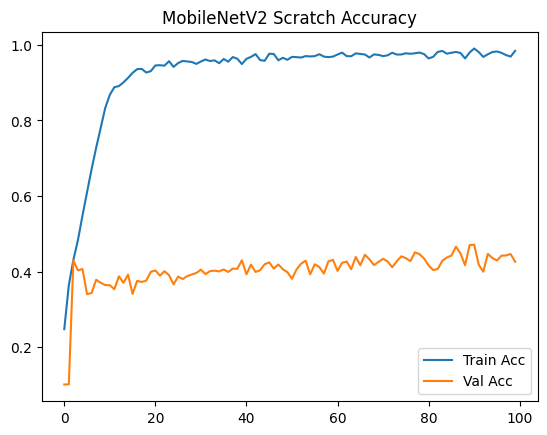

123/123 ━━━━━━━━━━━━━━━━━━━━ 9s 50ms/step


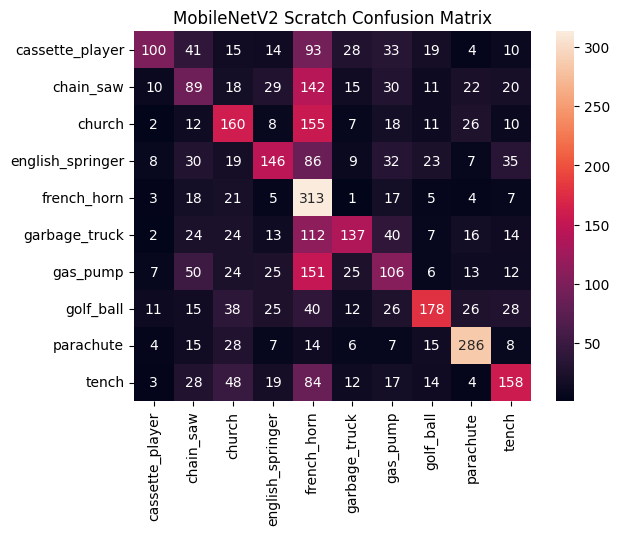

                  precision    recall  f1-score   support

 cassette_player       0.67      0.28      0.39       357
       chain_saw       0.28      0.23      0.25       386
          church       0.41      0.39      0.40       409
english_springer       0.50      0.37      0.43       395
     french_horn       0.26      0.79      0.40       394
   garbage_truck       0.54      0.35      0.43       389
        gas_pump       0.33      0.25      0.28       419
       golf_ball       0.62      0.45      0.52       399
       parachute       0.70      0.73      0.72       390
           tench       0.52      0.41      0.46       387

        accuracy                           0.43      3925
       macro avg       0.48      0.43      0.43      3925
    weighted avg       0.48      0.43      0.43      3925

MobileNetV2 Scratch ROC AUC: 0.8091117303469322


In [ ]:
# Accuracy plot
plt.plot(history_mobilenetv2_scratch.history['accuracy'], label='Train Acc')
plt.plot(history_mobilenetv2_scratch.history['val_accuracy'], label='Val Acc')
plt.legend(); plt.title("MobileNetV2 Scratch Accuracy"); plt.show()

# Predictions
y_true = np.concatenate([y.numpy() for _,y in val_ds], axis=0)
y_pred = mobilenetv2_scratch.predict(val_ds)
y_pred_classes = np.argmax(y_pred, axis=1)
y_true_classes = np.argmax(y_true, axis=1)

# Confusion Matrix
cm = confusion_matrix(y_true_classes, y_pred_classes)
sns.heatmap(cm, annot=True, fmt='d', xticklabels=class_names, yticklabels=class_names)
plt.title("MobileNetV2 Scratch Confusion Matrix"); plt.show()

# Classification Report
print(classification_report(y_true_classes, y_pred_classes, target_names=class_names))

# ROC AUC
roc_auc = roc_auc_score(y_true, y_pred, multi_class='ovr')
print("MobileNetV2 Scratch ROC AUC:", roc_auc)

**Analysis:** The MobileNetV2 model trained from scratch struggled to predict properly. The training accuracy improved, but validation accuracy stayed low and unstable, which shows it could not predict properly to the new data. The confusion matrix shows uneven predictions, with some classes were classified properly and others were not. The classification report shows this imbalance, with overall accuracy of 43%. The ROC AUC score was 81%, meaning the model could make predictions somewhat but not classify them consistently.

## Pretrained MobileNetV2

In [ ]:
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.layers import GlobalAveragePooling2D, Dense, Dropout
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam

base_model = MobileNetV2(input_shape=(160, 160, 3), include_top=False, weights='imagenet')
base_model.trainable = False  # freeze model

# add classification layer
x = base_model.output
x = GlobalAveragePooling2D()(x)
x = Dense(256, activation='relu')(x)
x = Dropout(0.5)(x)
outputs = Dense(num_classes, activation='softmax')(x)

# train classification layer
mobilenetv2_pretrained = Model(inputs=base_model.input, outputs=outputs)
mobilenetv2_pretrained.compile(optimizer=Adam(learning_rate=1e-4), loss='categorical_crossentropy', metrics=['accuracy'])
history = mobilenetv2_pretrained.fit(train_ds, validation_data=val_ds, epochs=15)

# unfreeze model
base_model.trainable = True

# freeze lower (starting) layers (to keep the general features of the dataset)
for layer in base_model.layers[:100]:
    layer.trainable = False

# train last layer and classifcation layer of the model
mobilenetv2_pretrained.compile(optimizer=Adam(learning_rate=1e-5), loss='categorical_crossentropy', metrics=['accuracy'])
history_mobilenetv2_pretrained = mobilenetv2_pretrained.fit(train_ds, validation_data=val_ds, epochs=20)

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 3s 0us/step
Epoch 1/15
296/296 ━━━━━━━━━━━━━━━━━━━━ 36s 82ms/step - accuracy: 0.6275 - loss: 1.2109 - val_accuracy: 0.9521 - val_loss: 0.2821
Epoch 2/15
296/296 ━━━━━━━━━━━━━━━━━━━━ 7s 23ms/step - accuracy: 0.8254 - loss: 0.5578 - val_accuracy: 0.9628 - val_loss: 0.1744
Epoch 3/15
296/296 ━━━━━━━━━━━━━━━━━━━━ 7s 23ms/step - accuracy: 0.8634 - loss: 0.4403 - val_accuracy: 0.9664 - val_loss: 0.1389
Epoch 4/15
296/296 ━━━━━━━━━━━━━━━━━━━━ 7s 22ms/step - accuracy: 0.8812 - loss: 0.3749 - val_accuracy: 0.9682 - val_loss: 0.1217
Epoch 5/15
296/296 ━━━━━━━━━━━━━━━━━━━━ 7s 22ms/step - accuracy: 0.8914 - loss: 0.3309 - val_accuracy: 0.9697 - val_loss: 0.1121
Epoch 6/15
296/296 ━━━━━━━━━━━━━━━━━━━━ 7s 22ms/step - accuracy: 0.9051 - loss: 0.2960 - val_accuracy: 0.9682 - val_loss: 0.1100
Epoch 7/15
296/296 ━━━━━━━━━━━━━━━━━━━━ 7s 22ms/step - accuracy: 0.9136 - loss: 0.2707 - val_accuracy: 0.9697 - val_loss: 0.1053
Epoch 8/15
296/296 ━━━━━━━━━━━━━━━━━━━━ 7s 23ms

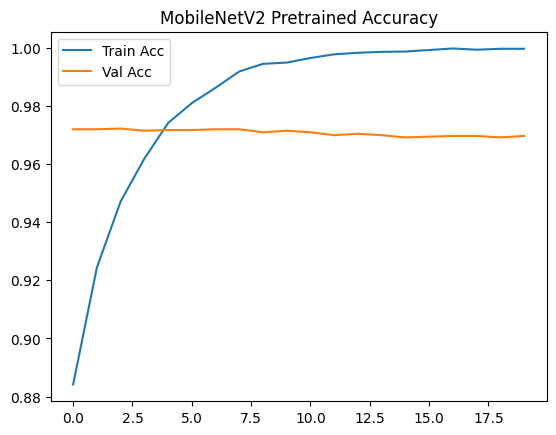

123/123 ━━━━━━━━━━━━━━━━━━━━ 12s 53ms/step


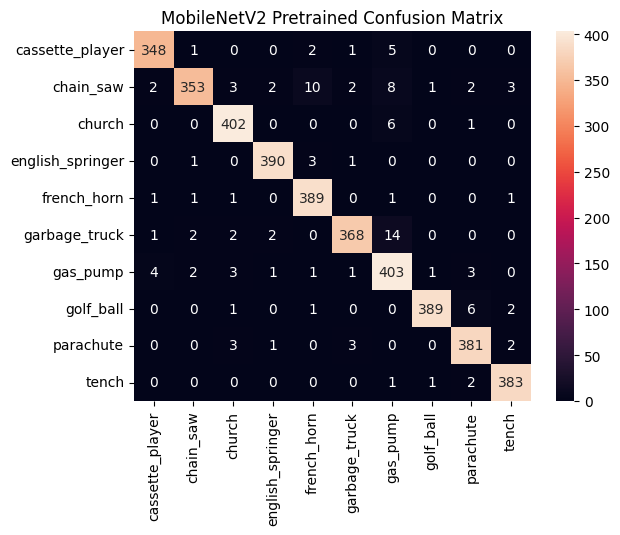

                  precision    recall  f1-score   support

 cassette_player       0.98      0.97      0.98       357
       chain_saw       0.98      0.91      0.95       386
          church       0.97      0.98      0.98       409
english_springer       0.98      0.99      0.99       395
     french_horn       0.96      0.99      0.97       394
   garbage_truck       0.98      0.95      0.96       389
        gas_pump       0.92      0.96      0.94       419
       golf_ball       0.99      0.97      0.98       399
       parachute       0.96      0.98      0.97       390
           tench       0.98      0.99      0.98       387

        accuracy                           0.97      3925
       macro avg       0.97      0.97      0.97      3925
    weighted avg       0.97      0.97      0.97      3925

MobileNetV2 Pretrained ROC AUC: 0.9989349162769499


In [ ]:
# Accuracy plot
plt.plot(history_mobilenetv2_pretrained.history['accuracy'], label='Train Acc')
plt.plot(history_mobilenetv2_pretrained.history['val_accuracy'], label='Val Acc')
plt.legend(); plt.title("MobileNetV2 Pretrained Accuracy"); plt.show()

# Predictions
y_true = np.concatenate([y.numpy() for _,y in val_ds], axis=0)
y_pred = mobilenetv2_pretrained.predict(val_ds)
y_pred_classes = np.argmax(y_pred, axis=1)
y_true_classes = np.argmax(y_true, axis=1)

# Confusion Matrix
cm = confusion_matrix(y_true_classes, y_pred_classes)
sns.heatmap(cm, annot=True, fmt='d', xticklabels=class_names, yticklabels=class_names)
plt.title("MobileNetV2 Pretrained Confusion Matrix"); plt.show()

# Classification Report
print(classification_report(y_true_classes, y_pred_classes, target_names=class_names))

# ROC AUC
roc_auc = roc_auc_score(y_true, y_pred, multi_class='ovr')
print("MobileNetV2 Pretrained ROC AUC:", roc_auc)

**Analysis:** The pretrained MobileNetV2 model performed good. The training accuracy quickly climbed well, while validation accuracy stayed stable, this shows the model could make predictions properly to new data. The accuracy plot shows this movement. The confusion matrix shows most classes predicted correctly with few mistakes, which means the model was consistent on all categories. The classification report shows high precision, recall, and f1‑scores on all classes, and overall accuracy is 97%. The ROC AUC score was also high, close to one, which means the model could make predictions reliably.

**Comparison:** The comparison between the MobileNetV2 models trained from scratch and pretrained shows a huge difference in performance. The scratch model reached 43% accuracy, with unstable predictions on some classes. Its confusion matrix and classification report shows that some categories were classified while others were not, and the ROC AUC score of 81% shows moderate predicting ability but weak in classification. In contrast, the pretrained MobileNetV2 achieved around 97% accuracy with stable validation accuracy, balanced predictions on all classes, and high precision, recall, and f1‑scores. Its ROC AUC score was close to one, which means predictions were reliable.


# Conclusion

- **Fernandez:** In this laboraotry activity, I learned that models trained from scratch can learn patterns but struggle to perform well on new data, while pretrained models perform much better because they already have knowledge fomr larger dataset. Based on the results, pretrained VGG16 and MobileNetV2 gave higher accuracy, more stable predictions, and better overall performance, this proves that using pretrained models is more effective and reliable for image classification.

- **Valleser:** From the analysis, it is clear that starting a model from zero makes it harder to generalize, leading to lower accuracy and unstable results, while pretrained models adapt faster and produce more accurate and balanced outputs. The results confirm that transfer learning is a better approach since it saves time, improves performance, and handles different classes more consistently compared to models trained from scratch.